<a href="https://colab.research.google.com/github/httpsdluc/eda-technical-practice/blob/main/customer_transactions_campagins_analysis/notebooks/customer_transactions_campagins_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
df_campaign = pd.read_csv('../data/Campaigns_from_Gmail.csv')
df_customers = pd.read_csv('../data/Customers.csv')
df_transactions = pd.read_csv('../data/Transactions_from_Gmail.csv')

1. how many unique customers are there?

In [3]:
df_customers.head()

,customer_id,age,annual_income,spending_score
0,1000,56,61905,66
1,1001,69,41258,40
2,1002,46,89176,67
3,1003,32,57699,71
4,1004,60,46395,65


In [4]:
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   customer_id     200 non-null    int64
 1   age             200 non-null    int64
 2   annual_income   200 non-null    int64
 3   spending_score  200 non-null    int64
dtypes: int64(4)
memory usage: 6.4 KB


In [5]:
df_customers.shape

(200, 4)

In [6]:
df_customers.describe()

,customer_id,age,annual_income,spending_score
count,200.000000,200.00000,200.000000,200.000000
mean,1099.500000,43.42500,59990.615000,59.000000
std,57.879185,14.94191,15861.517489,18.380129
min,1000.000000,18.00000,16808.000000,8.000000
25%,1049.750000,31.00000,49401.000000,45.750000
50%,1099.500000,43.50000,59877.500000,61.000000
75%,1149.250000,56.00000,70807.500000,71.000000
max,1199.000000,69.00000,107805.000000,108.000000


In [7]:
df_copy = df_customers['customer_id'].value_counts().reset_index()

In [8]:
df_customers['customer_id'].nunique()

200

In [9]:
df_copy

,customer_id,count
0,1000,1
1,1137,1
2,1127,1
3,1128,1
4,1129,1
...,...,...
195,1069,1
196,1070,1
197,1071,1
198,1072,1


In [10]:
int(df_copy['count'].sum())

200

2. What is the average annual income?

In [11]:
float(df_customers['annual_income'].mean())

59990.615

3. How many transactions are there?

In [12]:
df_transactions.head()

,customer_id,transaction_amount
0,1000,11.51
1,1000,32.54
2,1000,61.43
3,1000,-18.18
4,1000,14.74


In [13]:
df_transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2327 entries, 0 to 2326
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         2327 non-null   int64  
 1   transaction_amount  2327 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 36.5 KB


In [14]:
df_transactions.shape

(2327, 2)

In [15]:
df_transactions.describe()

,customer_id,transaction_amount
count,2327.000000,2327.000000
mean,1098.225183,31.179450
std,57.198700,21.968533
min,1000.000000,-37.170000
25%,1049.500000,16.270000
50%,1097.000000,31.640000
75%,1147.000000,46.080000
max,1199.000000,102.170000


In [16]:
df_transactions['transaction_amount'].count()

np.int64(2327)

4. What is the percentage of people who recieved response?

In [17]:
df_campaign.head()

,customer_id,channel,offer_type,responded
0,1000,push,loyalty_points,1
1,1000,sms,cashback,0
2,1000,push,loyalty_points,1
3,1000,email,loyalty_points,1
4,1001,email,bundle,1


In [18]:
df_campaign.describe()

,customer_id,responded
count,699.000000,699.000000
mean,1100.786838,0.399142
std,58.022069,0.490073
min,1000.000000,0.000000
25%,1051.000000,0.000000
50%,1101.000000,0.000000
75%,1153.000000,1.000000
max,1199.000000,1.000000


In [19]:
sum_responses = int((df_campaign['responded'] == 1).sum())

In [20]:
total_responses = int(df_campaign['responded'].count())

In [21]:
percent_responses = (sum_responses/total_responses) * 100

In [22]:
print(percent_responses)

39.91416309012876


5. What is the total spend per customer?

In [23]:
df_transactions.head()

,customer_id,transaction_amount
0,1000,11.51
1,1000,32.54
2,1000,61.43
3,1000,-18.18
4,1000,14.74


In [24]:
df_transactions.shape

(2327, 2)

In [25]:
# making a dataframe that groups customer_id by transaction_amount sums
df_totalspend = df_transactions.groupby('customer_id')['transaction_amount'].sum().reset_index()

In [26]:
# ensures all rows are shown
pd.set_option('display.max_rows', None)

In [37]:
df_totalspend.head(200)

,customer_id,transaction_amount
0,1000,375.68
1,1001,404.54
2,1002,726.00
3,1003,344.94
4,1004,177.52
5,1005,374.00
6,1006,300.69
7,1007,288.17
8,1008,203.41
9,1009,214.62


6. Is income correlated with total spending?

In [28]:
df_merge_totalspending = pd.merge(df_customers, df_totalspend, on = 'customer_id', how = 'inner')

In [29]:
df_merge_totalspending.head()

,customer_id,age,annual_income,spending_score,transaction_amount
0,1000,56,61905,66,375.68
1,1001,69,41258,40,404.54
2,1002,46,89176,67,726.00
3,1003,32,57699,71,344.94
4,1004,60,46395,65,177.52


In [32]:
# df['col1'].corr(df['col2']): Calculates the correlation between two specific columns (Series).

float(df_merge_totalspending['annual_income'].corr(df_merge_totalspending['transaction_amount'])) 

0.5781537793912465

In [34]:
df_merge_totalspending[['age', 'annual_income', 'spending_score', 'transaction_amount']].corr()

,age,annual_income,spending_score,transaction_amount
age,1.000000,0.099225,0.091561,0.098291
annual_income,0.099225,1.000000,0.820258,0.578154
spending_score,0.091561,0.820258,1.000000,0.510285
transaction_amount,0.098291,0.578154,0.510285,1.000000


<Axes: xlabel='annual_income', ylabel='transaction_amount'>

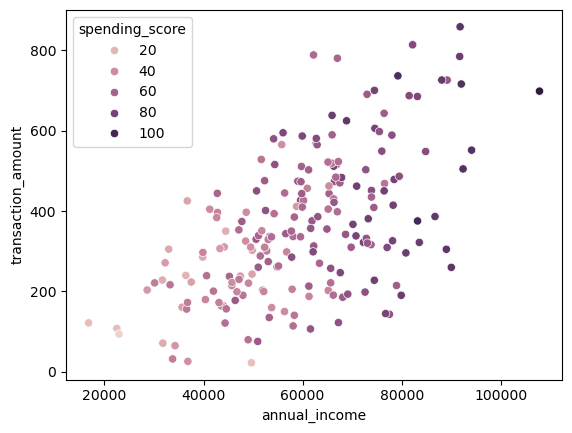

In [42]:
sns.scatterplot(data = df_merge_totalspending, x = 'annual_income', y = 'transaction_amount', hue = 'spending_score')

7. Which channel has the highest response rate?

In [44]:
df_campaign.head()

,customer_id,channel,offer_type,responded
0,1000,push,loyalty_points,1
1,1000,sms,cashback,0
2,1000,push,loyalty_points,1
3,1000,email,loyalty_points,1
4,1001,email,bundle,1


In [45]:
df_response = df_campaign.groupby('channel')['responded'].sum().reset_index()

In [47]:
df_response.max()

channel      sms
responded     80
dtype: object

8. Do high spending_score customers actually spend more?

In [48]:
df_highspending = df_merge_totalspending.groupby('customer_id')['spending_score','transaction_amount']

ValueError: Cannot subset columns with a tuple with more than one element. Use a list instead.

9. Which offer_type performs best?

10. Do customers with more transactions respond more to campaigns?

11. Build customer segments (e.g. low / mid / high income). Compare:
avg spend
response rate

12. Which combination performs best? (channel + offer_type)

13. Find “high-value but low-response” customers


14. Outlier detection:

15. Build a simple model: predict responded
Features:
income
spending_score
avg transaction
transaction count